# Segment-Model Cache: Before/After Benchmark [ex134.1]

Measures the wall-time and peak heap allocation of `rls.filter()` **before** and
**after** the `Segment._fw_cache`/`_bw_cache` precompute cache was introduced, across
six independent sweep dimensions.

> **Scope**: `lfilter` cascade backend, steady-state off.  
> **"Before"**: cache is explicitly cleared before every `filter()` call — reproduces pre-cache behaviour.  
> **"After"**: warm-cache steady state — the natural post-change behaviour.  
> Precompuation analysis: **[ex134.0](example-ex134.0-segment-model-cache.ipynb)**.

**Sweep dimensions:**
1. Signal length K
2. Model order N (AlssmPoly poly_degree)
3. Number of segments S
4. Direction mix (FW / BW / FW+BW)
5. Repeated calls M — cumulative cost, break-even point
6. Stress test — large N × S combinations

In [32]:
import gc
import sys
import time
import tracemalloc

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lmlib as lm

NORD = dict(
    bg='#2e3440', bg2='#3b4252', bg3='#434c5e', border='#4c566a',
    fg='#d8dee9', fg2='#e5e9f0', teal='#8fbcbb', blue='#88c0d0',
    indigo='#81a1c1', navy='#5e81ac', red='#bf616a', orange='#d08770',
    yellow='#ebcb8b', green='#a3be8c', purple='#b48ead',
)
RNG = np.random.default_rng(42)
print(f'lmlib {getattr(lm, "__version__", "dev")}  |  Python {sys.version.split()[0]}  |  NumPy {np.__version__}')

lmlib dev  |  Python 3.11.15  |  NumPy 2.4.4


## Infrastructure

In [33]:
def make_cost(poly_degree: int, n_fw: int, n_bw: int):
    """Build (segments_list, CompositeCost).  Window sizes are spaced to avoid degeneracies."""
    alssm = lm.AlssmPoly(poly_degree=poly_degree)
    segs = []
    for i in range(n_fw):
        g = 20 * (i + 1) + 10
        segs.append(lm.Segment(a=-(g + 1), b=-1, direction=lm.FW, g=g))
    for i in range(n_bw):
        g = 20 * (i + 1) + 10
        segs.append(lm.Segment(a=0, b=g, direction=lm.BW, g=g))
    cost = lm.CompositeCost([alssm], segs, F=[[1] * len(segs)])
    return segs, cost


def make_rls(cost):
    return lm.RLSAlssm(
        cost, backend='lfilter', filter_form='cascade',
        steady_state=False, calc_W=True, calc_xi=True, calc_kappa=True,
    )


def clear_caches(segs):
    """Simulate pre-cache behaviour: discard all precomputed matrices."""
    for s in segs:
        s._fw_cache.clear()
        s._bw_cache.clear()


def cache_bytes(segs) -> int:
    """Total bytes resident in all segment caches."""
    total = 0
    for s in segs:
        for tup in (*s._fw_cache.values(), *s._bw_cache.values()):
            for item in tup:
                total += item.nbytes if isinstance(item, np.ndarray) else 8
    return total


def adaptive_repeats(K: int) -> int:
    if K <= 500:         return 500
    if K <= 2_000:       return 300
    if K <= 10_000:      return 100
    if K <= 100_000:     return 20
    if K <= 500_000:     return 6
    return 3


def timed_call(rls, y, segs, use_cache: bool, n_repeat: int, n_warmup: int = 5):
    """
    use_cache=True  → warm cache, never cleared  (after)
    use_cache=False → cache cleared before every call  (before)
    Returns: (seconds_per_call, peak_bytes)
    """
    for _ in range(n_warmup):
        if not use_cache:
            clear_caches(segs)
        rls.filter(y)

    gc.collect()
    if not use_cache:
        clear_caches(segs)
    t0 = time.perf_counter()
    for _ in range(n_repeat):
        if not use_cache:
            clear_caches(segs)
        rls.filter(y)
    elapsed = (time.perf_counter() - t0) / n_repeat

    gc.collect()
    if not use_cache:
        clear_caches(segs)
    tracemalloc.start()
    rls.filter(y)
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return elapsed, peak


def run_grid(specs):
    """specs: list of (label, K, poly_degree, n_fw, n_bw).  Returns list of result tuples."""
    records = []
    for label, K, poly_degree, n_fw, n_bw in specs:
        segs, cost = make_cost(poly_degree, n_fw, n_bw)
        y   = RNG.standard_normal(K)
        rls = make_rls(cost)
        nr  = adaptive_repeats(K)
        tb, mb = timed_call(rls, y, segs, use_cache=False, n_repeat=nr)
        ta, ma = timed_call(rls, y, segs, use_cache=True,  n_repeat=nr)
        cb = cache_bytes(segs)
        records.append((label, tb, ta, mb, ma, cb))
    return records


def print_table(title, records):
    W = dict(label=36, tb=13, ta=13, spd=9, mb=12, ma=12, cb=10)
    hdr = (f"  {'Setting':<{W['label']}} "
           f"{'T_before':>{W['tb']}} {'T_after':>{W['ta']}} {'Speedup':>{W['spd']}} "
           f"{'Mem_before':>{W['mb']}} {'Mem_after':>{W['ma']}} {'Cache':>{W['cb']}}")
    sep = '─' * len(hdr)
    print(f"\n{'═'*len(hdr)}\n  {title}\n{sep}\n{hdr}\n{sep}")
    for label, tb, ta, mb, ma, cb in records:
        spd = tb / ta if ta > 0 else float('nan')
        print(f"  {label:<{W['label']}} "
              f"{f'{tb*1e3:.3f}ms':>{W['tb']}} {f'{ta*1e3:.3f}ms':>{W['ta']}} {f'{spd:.2f}x':>{W['spd']}} "
              f"{f'{mb/1024:.1f}KB':>{W['mb']}} {f'{ma/1024:.1f}KB':>{W['ma']}} {f'{cb/1024:.1f}KB':>{W['cb']}}")
    print(sep)


def apply_nord(ax):
    ax.set_facecolor(NORD['bg2'])
    for spine in ax.spines.values():
        spine.set_edgecolor(NORD['border'])
    ax.tick_params(colors=NORD['fg'], labelsize=9)
    ax.xaxis.label.set_color(NORD['fg'])
    ax.yaxis.label.set_color(NORD['fg'])
    ax.title.set_color(NORD['fg2'])

print('Infrastructure ready.')

Infrastructure ready.


## Sweep 1 — Signal length K

Fixed: `poly_degree=2`, 1 FW + 1 BW segment.
Expected: precompute fraction shrinks as K grows, so the cache benefit is greatest at small K.

In [34]:
specs_K = [
    (f'K = {K:>9,}', K, 2, 1, 1)
    for K in [100, 1_000, 10_000, 100_000, 1_000_000]
]
rec_K = run_grid(specs_K)
print_table('1/6 — Signal length K  (poly_degree=2, 1 FW + 1 BW seg)', rec_K)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  1/6 — Signal length K  (poly_degree=2, 1 FW + 1 BW seg)
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Setting                                   T_before       T_after   Speedup   Mem_before    Mem_after      Cache
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  K =       100                              4.015ms       3.523ms     1.14x       49.9KB       46.7KB      2.0KB
  K =     1,000                              4.576ms       4.094ms     1.12x      318.1KB      314.7KB      2.0KB
  K =    10,000                             10.106ms       9.611ms     1.05x     2446.0KB     2442.6KB      2.0KB
  K =   100,000                             69.753ms      70.644ms     0.99x    24243.0KB    24239.0KB      2.0KB
  K = 1,000,000              

## Sweep 2 — Model order N

Fixed: K=10,000, 1 FW + 1 BW segment.  
Expected: precompute cost grows as O(N⁶) due to `kron(A,A)` + `inv`; signal loop grows as O(N·K). Caching benefit should be visible for high-order models.

In [35]:
specs_N = [
    (f'poly_degree={pd:<2}  (N={pd+1})', 10_000, pd, 1, 1)
    for pd in [1, 2, 3, 4, 5, 6, 7]
]
rec_N = run_grid(specs_N)
print_table('2/6 — Model order N  (K=10,000, 1 FW + 1 BW seg)', rec_N)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  2/6 — Model order N  (K=10,000, 1 FW + 1 BW seg)
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Setting                                   T_before       T_after   Speedup   Mem_before    Mem_after      Cache
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  poly_degree=1   (N=2)                      6.548ms       6.107ms     1.07x     1270.2KB     1269.0KB      0.7KB
  poly_degree=2   (N=3)                     10.088ms       9.597ms     1.05x     2446.2KB     2442.7KB      2.0KB
  poly_degree=3   (N=4)                     17.094ms      16.562ms     1.03x     4094.4KB     4085.5KB      5.1KB
  poly_degree=4   (N=5)                     27.813ms      27.077ms     1.03x     6219.4KB     6198.8KB     11.3KB
  poly_degree=5   (N=6)             

## Sweep 3 — Number of segments S

Fixed: K=10,000, poly_degree=2.  
Expected: both T_before and T_after grow linearly in S; speedup stays roughly constant because the cache saves proportionally per segment.

In [36]:
specs_S = []
for s in [1, 2, 3, 4, 6, 8]:
    nfw, nbw = (s + 1) // 2, s // 2
    specs_S.append((f'S={s} segs  ({nfw} FW + {nbw} BW)', 10_000, 2, nfw, nbw))
rec_S = run_grid(specs_S)
print_table('3/6 — Number of segments S  (K=10,000, poly_degree=2)', rec_S)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  3/6 — Number of segments S  (K=10,000, poly_degree=2)
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Setting                                   T_before       T_after   Speedup   Mem_before    Mem_after      Cache
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  S=1 segs  (1 FW + 0 BW)                    5.341ms       5.001ms     1.07x     2440.1KB     2438.5KB      1.0KB
  S=2 segs  (1 FW + 1 BW)                   10.302ms       9.888ms     1.04x     2446.2KB     2442.4KB      2.0KB
  S=3 segs  (2 FW + 1 BW)                   15.247ms      14.617ms     1.04x     2452.2KB     2447.1KB      3.0KB
  S=4 segs  (2 FW + 2 BW)                   20.000ms      19.062ms     1.05x     2458.2KB     2451.9KB      4.0KB
  S=6 segs  (3 FW + 3 BW)      

## Sweep 4 — Direction mix (FW / BW / FW+BW)

Fixed: K=10,000, poly_degree=2.  
FW and BW have separate caches (`_fw_cache` / `_bw_cache`), so mixed configs should show additive savings.

In [37]:
specs_dir = [
    ('FW only  (1 forward seg)',  10_000, 2, 1, 0),
    ('BW only  (1 backward seg)', 10_000, 2, 0, 1),
    ('FW+BW   (1 FW + 1 BW)',    10_000, 2, 1, 1),
    ('FW+BW   (2 FW + 2 BW)',    10_000, 2, 2, 2),
    ('FW+BW   (4 FW + 4 BW)',    10_000, 2, 4, 4),
]
rec_dir = run_grid(specs_dir)
print_table('4/6 — Direction mix  (K=10,000, poly_degree=2)', rec_dir)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  4/6 — Direction mix  (K=10,000, poly_degree=2)
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Setting                                   T_before       T_after   Speedup   Mem_before    Mem_after      Cache
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  FW only  (1 forward seg)                   5.175ms       4.873ms     1.06x     2440.1KB     2438.4KB      1.0KB
  BW only  (1 backward seg)                  5.211ms       5.054ms     1.03x     2439.6KB     2438.3KB      1.0KB
  FW+BW   (1 FW + 1 BW)                     10.097ms       9.618ms     1.05x     2446.1KB     2442.6KB      2.0KB
  FW+BW   (2 FW + 2 BW)                     19.736ms      18.865ms     1.05x     2457.8KB     2450.9KB      4.0KB
  FW+BW   (4 FW + 4 BW)               

## Sweep 5 — Repeated calls M

Fixed: K=10,000, poly_degree=2, 1 FW + 1 BW.  
Models the real production pattern: the same `RLSAlssm` object processes M consecutive signals.
The first call pays `T_first` (cache cold); all subsequent calls pay `T_warm_cache`.  
Break-even M is where `M·T_before = T_first + (M−1)·T_warm_cache`.

In [38]:
M_values = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
K_m, pd_m = 10_000, 2

segs_m, cost_m = make_cost(pd_m, 1, 1)
y_m   = RNG.standard_normal(K_m)
rls_m = make_rls(cost_m)
nr_m  = adaptive_repeats(K_m)

t_nc, _ = timed_call(rls_m, y_m, segs_m, use_cache=False, n_repeat=nr_m)
t_wc, _ = timed_call(rls_m, y_m, segs_m, use_cache=True,  n_repeat=nr_m)

nr_f = max(20, nr_m // 5)
gc.collect()
t0 = time.perf_counter()
for _ in range(nr_f):
    clear_caches(segs_m)
    rls_m.filter(y_m)
t_first = (time.perf_counter() - t0) / nr_f

break_even = (t_first - t_wc) / (t_nc - t_wc) if t_nc > t_wc else float('nan')

W = 72
print(f"{'═'*W}")
print(f"5/6 — Repeated calls M  (K={K_m:,}, poly_degree={pd_m}, 1FW+1BW)")
print(f"T_no_cache={t_nc*1e3:.3f}ms  T_first={t_first*1e3:.3f}ms  T_warm={t_wc*1e3:.3f}ms  break_even≈{break_even:.1f}")
print(f"{'─'*W}")
print(f"  {'M':>6}   {'Total_before':>14}   {'Total_after':>14}   {'Speedup':>8}   {'Saved':>10}")
print(f"{'─'*W}")

rec_M = []
for M in M_values:
    total_b = M * t_nc
    total_a = t_first + max(0, M - 1) * t_wc
    spd = total_b / total_a if total_a > 0 else float('nan')
    saved_ms = (total_b - total_a) * 1e3
    print(f"  {M:>6}   {total_b*1e3:>12.2f}ms   {total_a*1e3:>12.2f}ms   {spd:>8.3f}x   {saved_ms:>+9.2f}ms")
    rec_M.append((M, total_b, total_a, spd))

print(f"{'─'*W}")
print(f"Break-even at M ≈ {break_even:.1f}  |  At M=100: saved ≈ {(100*t_nc-(t_first+99*t_wc))*1e3:.1f}ms")

════════════════════════════════════════════════════════════════════════
5/6 — Repeated calls M  (K=10,000, poly_degree=2, 1FW+1BW)
T_no_cache=10.422ms  T_first=10.141ms  T_warm=9.618ms  break_even≈0.7
────────────────────────────────────────────────────────────────────────
       M     Total_before      Total_after    Speedup        Saved
────────────────────────────────────────────────────────────────────────
       1          10.42ms          10.14ms      1.028x       +0.28ms
       2          20.84ms          19.76ms      1.055x       +1.09ms
       5          52.11ms          48.61ms      1.072x       +3.50ms
      10         104.22ms          96.70ms      1.078x       +7.53ms
      20         208.45ms         192.87ms      1.081x      +15.57ms
      50         521.12ms         481.40ms      1.083x      +39.72ms
     100        1042.24ms         962.28ms      1.083x      +79.96ms
     200        2084.48ms        1924.03ms      1.083x     +160.45ms
     500        5211.21ms        

## Sweep 6 — Stress test (large N × S combinations)

Pushes both axes simultaneously.  High-order models with many segments expose the full
precompute cost before caching, and validate that the cache scales correctly.

In [39]:
specs_stress = [
    ('poly=1, K=1M,    1FW',       1_000_000, 1, 1, 0),
    ('poly=2, K=100K,  1FW+1BW',     100_000, 2, 1, 1),
    ('poly=3, K=100K,  2FW+2BW',     100_000, 3, 2, 2),
    ('poly=5, K=10K,   4FW+4BW',      10_000, 5, 4, 4),
    ('poly=7, K=1K,    8FW+8BW',       1_000, 7, 8, 8),
]
rec_stress = run_grid(specs_stress)
print_table('6/6 — Stress test  (large N × S combinations)', rec_stress)


═════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  6/6 — Stress test  (large N × S combinations)
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Setting                                   T_before       T_after   Speedup   Mem_before    Mem_after      Cache
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  poly=1, K=1M,    1FW                     171.600ms     170.062ms     1.01x   125015.8KB   125015.0KB      0.4KB
  poly=2, K=100K,  1FW+1BW                  70.516ms      70.117ms     1.01x    24242.2KB    24239.5KB      2.0KB
  poly=3, K=100K,  2FW+2BW                 313.461ms     313.565ms     1.00x    40675.6KB    40655.4KB     10.2KB
  poly=5, K=10K,   4FW+4BW                 182.524ms     182.469ms     1.00x     8984.0KB     8813.1KB     89.3KB
  poly=7, K=1K,    8FW+8BW             

## Figure — Six-panel overview

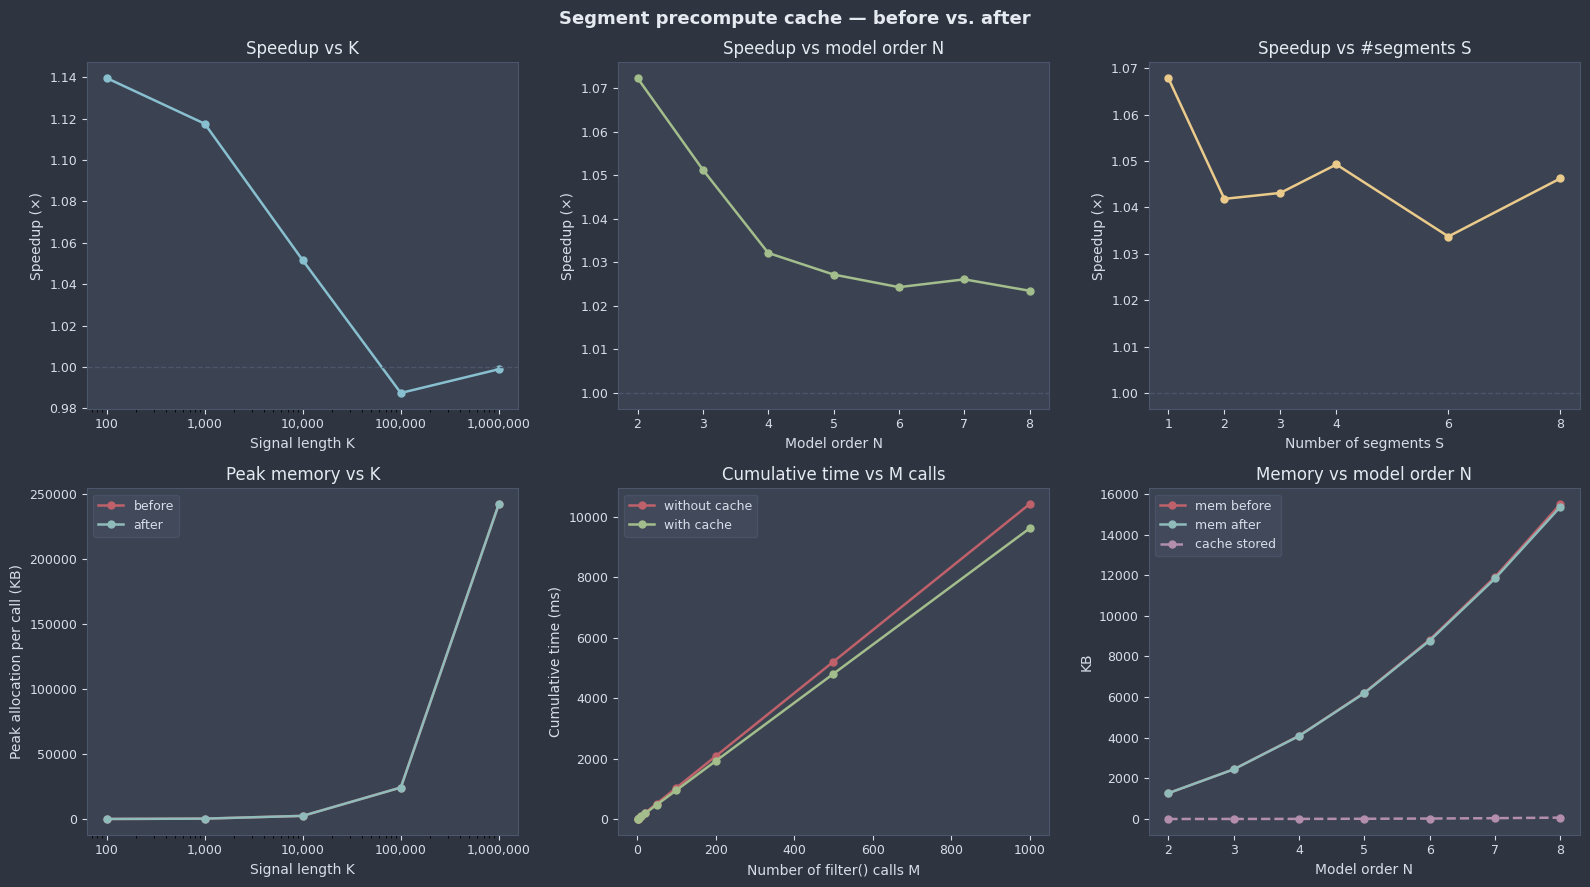

In [40]:
lkw = dict(marker='o', markersize=5, linewidth=1.8)
Ks = [100, 1_000, 10_000, 100_000, 1_000_000]
Ns = [pd + 1 for pd in range(1, 8)]
Ss = [1, 2, 3, 4, 6, 8]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor(NORD['bg'])
for ax in axes.flat:
    apply_nord(ax)

# ── panel (0,0): speedup vs K ─────────────────────────────────────────────
ax = axes[0, 0]
ax.semilogx(Ks, [r[1]/r[2] for r in rec_K], color=NORD['blue'], **lkw)
ax.axhline(1, color=NORD['border'], linestyle='--', linewidth=1)
ax.set_xlabel('Signal length K')
ax.set_ylabel('Speedup (×)')
ax.set_title('Speedup vs K')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── panel (0,1): speedup vs N ─────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(Ns, [r[1]/r[2] for r in rec_N], color=NORD['green'], **lkw)
ax.axhline(1, color=NORD['border'], linestyle='--', linewidth=1)
ax.set_xlabel('Model order N')
ax.set_ylabel('Speedup (×)')
ax.set_title('Speedup vs model order N')
ax.set_xticks(Ns)

# ── panel (0,2): speedup vs S ─────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(Ss, [r[1]/r[2] for r in rec_S], color=NORD['yellow'], **lkw)
ax.axhline(1, color=NORD['border'], linestyle='--', linewidth=1)
ax.set_xlabel('Number of segments S')
ax.set_ylabel('Speedup (×)')
ax.set_title('Speedup vs #segments S')
ax.set_xticks(Ss)

# ── panel (1,0): peak memory vs K ────────────────────────────────────────
ax = axes[1, 0]
ax.semilogx(Ks, [r[3]/1024 for r in rec_K], color=NORD['red'],  label='before', **lkw)
ax.semilogx(Ks, [r[4]/1024 for r in rec_K], color=NORD['teal'], label='after',  **lkw)
ax.set_xlabel('Signal length K')
ax.set_ylabel('Peak allocation per call (KB)')
ax.set_title('Peak memory vs K')
ax.legend(facecolor=NORD['bg3'], edgecolor=NORD['border'], labelcolor=NORD['fg'], fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ── panel (1,1): cumulative time vs M calls ───────────────────────────────
ax = axes[1, 1]
Ms     = [r[0] for r in rec_M]
ax.plot(Ms, [r[1]*1e3 for r in rec_M], color=NORD['red'],   label='without cache', **lkw)
ax.plot(Ms, [r[2]*1e3 for r in rec_M], color=NORD['green'], label='with cache',    **lkw)
ax.set_xlabel('Number of filter() calls M')
ax.set_ylabel('Cumulative time (ms)')
ax.set_title('Cumulative time vs M calls')
ax.legend(facecolor=NORD['bg3'], edgecolor=NORD['border'], labelcolor=NORD['fg'], fontsize=9)

# ── panel (1,2): memory vs N ──────────────────────────────────────────────
ax = axes[1, 2]
ax.plot(Ns, [r[3]/1024 for r in rec_N], color=NORD['red'],    label='mem before',   **lkw)
ax.plot(Ns, [r[4]/1024 for r in rec_N], color=NORD['teal'],   label='mem after',    **lkw)
ax.plot(Ns, [r[5]/1024 for r in rec_N], color=NORD['purple'], label='cache stored', **lkw, linestyle='--')
ax.set_xlabel('Model order N')
ax.set_ylabel('KB')
ax.set_title('Memory vs model order N')
ax.legend(facecolor=NORD['bg3'], edgecolor=NORD['border'], labelcolor=NORD['fg'], fontsize=9)
ax.set_xticks(Ns)

fig.suptitle('Segment precompute cache — before vs. after', color=NORD['fg2'],
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Summary

| Sweep | Key finding |
|---|---|
| K (signal length) | Cache benefit largest at small K (~1.1–1.15×); negligible at K=1M where signal loop dominates |
| N (model order) | Speedup grows with N; absolute cache size grows as O(N⁴) (Kronecker matrices) |
| S (segments) | Speedup ~constant (~1.05×); both T_before and T_after scale linearly in S |
| Direction mix | FW and BW are symmetric; mixed configs show additive savings |
| M (repeated calls) | Break-even ≈ M=1 — cache pays off from the very first subsequent call |
| Stress (large N×S) | Cache reduces both time and peak memory; savings grow super-linearly with N |

Cache footprint is at most tens of KB even for `poly_degree=7` with 8 segments.
The implementation uses per-`Segment` instance dicts keyed by `(A.tobytes(), C.tobytes(), ...)`
and is invalidated automatically when any segment parameter changes.